# L1b Derivation: Discrete Compounding and the Continuous Limit

This optional notebook extends the continuous-compounding discussion in the [L1b lecture notebook](./CHEME-5660-L1b-Lecture-TimeValueMoney-Fall-2026.ipynb). It asks how quickly a discrete accumulation factor approaches its continuous limit when the numerical annual-rate parameter is held fixed.

> __Learning Objectives:__
>
> By the end of this derivation, you should be able to:
> * __Separate the limit from the equivalent rate:__ Distinguish the fixed-rate continuous limit, which discrete compounding only approaches, from the equivalent continuous rate, which reproduces discrete compounding exactly at any finite compounding frequency.
> * __Derive the relative shortfall:__ Write the ratio of the discrete accumulation factor to its continuous limit in closed form, then expand the logarithm to obtain the leading estimate of how far the discrete factor falls short.
> * __Judge when the estimate is usable:__ Compare the leading estimate against exact values across compounding frequencies, and identify the quantity whose size, rather than the compounding frequency alone, decides whether the estimate can be trusted.

Let's get started!

___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. Our `Include.jl` searches upward from its own directory for the nearest `Project.toml`, activates that project, and calls [the `Pkg.instantiate()` function](https://pkgdocs.julialang.org/v1/api/#Pkg.instantiate) so the declared packages are installed before they are loaded.

For clarity, `include(joinpath(@__DIR__, "Include.jl"))` loads the `Include.jl` file that lives next to this notebook. The [`@__DIR__` macro](https://docs.julialang.org/en/v1/base/base/#Base.@__DIR__) expands to the directory containing the notebook, so this call works even if you open the notebook from a different working directory in VSCode.

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

___

## The Comparison

Let $y$ be a nominal annual-rate parameter, $n$ the number of compounding periods per year, and $T>0$ the horizon in years, chosen so that $nT$ is a whole number of periods. The discrete accumulation factor over $T$ years is
$$
\mathcal D_{T,0}(y;n)=\left(1+\frac{y}{n}\right)^{nT},
$$
and holding the numerical value of $y$ fixed while letting $n\rightarrow\infty$ gives the continuous limit $e^{yT}$.

That limit is a different statement from converting the discrete convention to its exactly equivalent continuous rate,
$$
g_y=n\log\left(1+\frac{y}{n}\right),
$$
for which $\mathcal D_{T,0}(y;n)=e^{g_yT}$ holds at every finite $n$. The equivalent rate closes the gap by construction; the fixed-$y$ limit leaves a gap that shrinks only as $n$ grows. This notebook measures that gap.

We build the discrete factors with the package's [`discount(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.discount-Tuple%7BAbstractCompoundingModel,%20Float64,%20Int64%7D), which retains its legacy name but returns forward accumulation factors in a dictionary keyed by period index. Those factors exist only at the compounding dates; the segments connecting them are a visual aid, not a model of growth in between.

Let's compare annual compounding, semiannual compounding, and the continuous limit at $y=10\%$ over $T=30$ years:

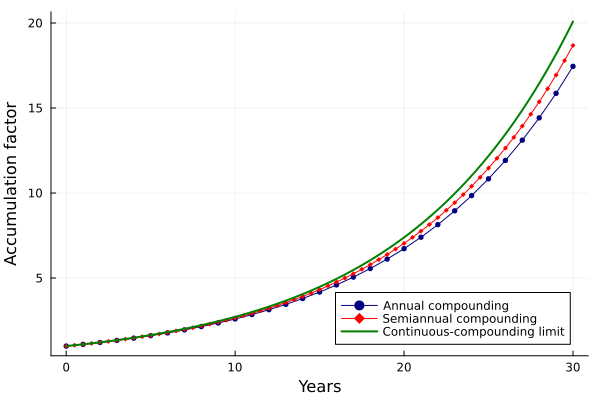

In [2]:
let

    # Initialize -
    discrete_compounding_model = DiscreteCompoundingModel(); # generate discrete accumulation factors
    T = 30.0; # common horizon (years)
    y = 0.10; # numerical annual-rate parameter held fixed across conventions (year⁻¹)
    n₁ = 1;   # compounding periods per year for the annual case
    n₂ = 2;   # compounding periods per year for the semiannual case

    N₁ = Int(n₁*T); # number of periods on the annual grid
    N₂ = Int(n₂*T); # number of periods on the semiannual grid
    𝒟(g,t) = exp(g*t); # continuous accumulation at rate g over elapsed time t

    # Compute the discrete accumulation factors; `discount(...)` is the legacy API name -
    accumulation_dictionary_case_1 = discount(discrete_compounding_model, y, N₁, λ = n₁); # annual grid
    accumulation_dictionary_case_2 = discount(discrete_compounding_model, y, N₂, λ = n₂); # semiannual grid

    # Convert the annual dictionary to [elapsed years, accumulation factor] rows -
    j₁ = keys(accumulation_dictionary_case_1) |> collect |> sort; # sort dictionary keys into plot order
    X₁ = Array{Float64,2}(undef, length(j₁),2); # preallocate the annual plotting array
    for i ∈ eachindex(j₁)
        j = j₁[i]; # financial index stored at array position i
        X₁[i,1] = j/n₁; # convert periods to elapsed years
        X₁[i,2] = accumulation_dictionary_case_1[j]; # copy the aligned factor
    end

    # Convert the semiannual dictionary to [elapsed years, accumulation factor] rows -
    j₂ = keys(accumulation_dictionary_case_2) |> collect |> sort; # sort dictionary keys into plot order
    X₂ = Array{Float64,2}(undef, length(j₂),2); # preallocate the semiannual plotting array
    for i ∈ eachindex(j₂)
        j = j₂[i]; # financial index stored at array position i
        X₂[i,1] = j/n₂; # convert periods to elapsed years
        X₂[i,2] = accumulation_dictionary_case_2[j]; # copy the aligned factor
    end

    # Sample the continuous-compounding limit -
    t₃ = 0:0.001:T |> collect; # fine time grid for a smooth reference curve
    X₃ = Array{Float64,2}(undef, length(t₃),2); # preallocate [time, factor] rows
    for i ∈ eachindex(t₃)
        t = t₃[i]; # elapsed time stored at array position i
        X₃[i,1] = t; # time coordinate
        X₃[i,2] = 𝒟(y,t); # continuous accumulation factor
    end

    # Markers identify the dates where each discrete model is defined. Connecting
    # segments guide the eye; they do not model value between compounding dates.
    plot(X₁[:,1], X₁[:,2], label = "Annual compounding", xlabel = "Years", ylabel = "Accumulation factor",
        legend = :bottomright, c=:navy, lw=1, markershape=:circle, markersize=3, markerstrokewidth=0)
    plot!(X₂[:,1], X₂[:,2], label = "Semiannual compounding", c=:red, lw=1,
        markershape=:diamond, markersize=2.5, markerstrokewidth=0)
    plot!(X₃[:,1], X₃[:,2], label = "Continuous-compounding limit", c=:green, lw=2)
end

All three factors equal one at $t=0$. At every annual date thereafter the semiannual factor lies strictly between the annual factor and the continuous limit, and each of the three pairwise gaps is wider than it was a year earlier. To attach numbers to that separation, compare the terminal accumulation factors at $T=30$ and the shortfall of each discrete case from the continuous limit:

In [3]:
let
    # Initialize -
    T = 30.0; # horizon (years)
    y = 0.10; # annual-rate parameter (year⁻¹)
    limit = exp(y*T); # continuous-compounding benchmark e^(yT)

    df = DataFrame(); # comparison table

    # Populate the discrete-compounding rows -
    for (convention, n) ∈ [("Annual (n = 1)", 1), ("Semiannual (n = 2)", 2)]
        terminal = (1 + y/n)^(n*T); # discrete factor (1 + y/n)^(nT)
        push!(df, (
            convention = convention,
            terminal = terminal,
            shortfall = 1 - terminal/limit, # fractional gap relative to the limit
        ));
    end

    push!(df, (convention = "Continuous limit", terminal = limit, shortfall = 0.0)); # add the zero-gap benchmark

    # Display the comparison -
    pretty_table(df; table_format = TextTableFormat(borders = text_table_borders__simple))
end

===================== ========== ============
          convention   terminal   shortfall 
              String    Float64     Float64 
===================== ========== ============
      Annual (n = 1)    17.4494    0.131245
  Semiannual (n = 2)    18.6792   0.0700181
    Continuous limit    20.0855         0.0
===================== ========== ============


Annual compounding ends about $13.1\%$ below the continuous limit, and semiannual compounding about $7.0\%$ below. The two conventions follow the same trend, but over a horizon this long they are not interchangeable.

___

## Deriving the Relative Shortfall

The table gives the gap for one choice of $y$ and $T$. A formula would tell us how the gap depends on all three parameters. Start from the ratio of the discrete accumulation factor to the continuous limit, and use $a^b=\exp(b\log a)$ to rewrite the discrete factor:
$$
\mathcal D_{T,0}(y;n)
=\exp\!\left[nT\log\!\left(1+\frac{y}{n}\right)\right].
$$
Dividing by $e^{yT}$ and using $e^a/e^b=e^{a-b}$ gives:
$$
\begin{align*}
\frac{\mathcal D_{T,0}(y;n)}{e^{yT}}
&=\frac{\exp\!\left[nT\log\!\left(1+\frac{y}{n}\right)\right]}{\exp(yT)}\\
&=\exp\!\left[nT\log\!\left(1+\frac{y}{n}\right)-yT\right].
\end{align*}
$$
Both steps are exact, and together they already fix the direction of the gap. Because $\log(1+x)<x$ for every $x>0$, the exponent $T\left[n\log(1+y/n)-y\right]$ is negative whenever $y>0$ and $T>0$, so the discrete factor lies strictly below $e^{yT}$ at every finite $n$. Define the __relative shortfall__ as:
$$
\delta_n:=1-\frac{\mathcal D_{T,0}(y;n)}{e^{yT}}.
$$
The approximation begins here. Expand the logarithm as $\log(1+x)=x-x^2/2+x^3/3-\cdots$, which converges for $-1<x\leq 1$. Setting $x=y/n$ therefore requires $y\leq n$, a condition every rate and frequency in this notebook satisfies:
$$
\begin{align*}
nT\log\!\left(1+\frac{y}{n}\right)
&=nT\left(\frac{y}{n}-\frac{y^2}{2n^2}+\frac{y^3}{3n^3}-\cdots\right)\\
&=yT-\frac{y^2T}{2n}+\frac{y^3T}{3n^2}-\cdots.
\end{align*}
$$
Substituting this result into the ratio yields the expression:
$$
\begin{align*}
\frac{\mathcal D_{T,0}(y;n)}{e^{yT}}
&=\exp\!\left(-\frac{y^2T}{2n}+\frac{y^3T}{3n^2}-\cdots\right).
\end{align*}
$$
When $y/n$ is small the series is dominated by its first term, and when the resulting exponent $y^2T/(2n)$ is small as well, $1-e^{-z}\approx z$ gives:
$$
\boxed{
\begin{align*}
\delta_n\approx \frac{y^2T}{2n}.
\end{align*}}
$$
Read as a scaling law, the shortfall grows with the horizon $T$ and roughly with the square of the rate $y$, and falls off as $1/n$, so doubling the compounding frequency roughly halves it. The result is __asymptotic__: it is accurate when the exponent $y^2T/(2n)$ is itself small, so a low compounding frequency, a long horizon, or a large rate each degrade it.

> __Do not confuse a limit with an equivalent rate.__ Every shortfall on this page comes from holding the numerical value of $y$ fixed and comparing $\mathcal D_{T,0}(y;n)$ with $e^{yT}$. Convert instead to the equivalent rate $g_y$ and there is no shortfall to estimate: that identity is exact at every finite $n$.

A more demanding case tests the estimate: at $y=15\%$ and $T=30$ years, compare the exact shortfall $\delta_n$ with $y^2T/(2n)$ across compounding frequencies from annual to daily.

Let's see how good the estimate is:

In [4]:
let
    # Initialize - change y and T here: the estimate also degrades with a longer
    # horizon or a larger rate, not only with a lower compounding frequency.
    T = 30.0; # horizon (years)
    y = 0.15; # annual-rate parameter (year⁻¹)

    df = DataFrame(); # comparison table

    # Compare the exact and approximate shortfalls from annual to daily compounding -
    for n ∈ [1, 2, 4, 12, 52, 365]
        exact = 1 - (1 + y/n)^(n*T)/exp(y*T); # relative shortfall from e^(yT)
        approximate = (y^2*T)/(2*n);          # leading term of the 1/n expansion
        push!(df, (
            n = n,
            exact = exact,
            approximate = approximate,
            relative_error = approximate/exact - 1, # signed error; positive means the estimate overstates
        ));
    end

    # Display how the approximation improves as n increases -
    pretty_table(df; table_format = TextTableFormat(borders = text_table_borders__simple))
end

======== ============= ============= =================
      n         exact   approximate   relative_error 
  Int64       Float64       Float64          Float64 
======== ============= ============= =================
      1      0.264454        0.3375         0.276216
      2      0.148504       0.16875         0.136334
      4     0.0790258      0.084375        0.0676897
     12     0.0275074      0.028125        0.0224526
     52    0.00645699    0.00649038       0.00517131
    365   0.000923977   0.000924658      0.000736364
======== ============= ============= =================


The estimate is off by about $27.6\%$ at annual compounding and about $13.6\%$ at semiannual compounding, which is why the terminal shortfalls were computed from the exact ratio rather than from the formula. The error falls to about $2.2\%$ at monthly compounding and below $0.1\%$ at daily compounding. Every error is positive, and that is not an accident: $\log(1+x)>x-x^2/2$ for $x>0$ holds the exact exponent below $y^2T/(2n)$, and $1-e^{-z}<z$ holds the shortfall below its own exponent, so the estimate overstates $\delta_n$ at every finite $n$. Use the exact ratio whenever $y^2T/(2n)$ is not small, and the leading estimate once it is.

___

## Summary

This notebook measured how far discrete compounding at a finite frequency falls below its fixed-rate continuous limit, and derived a formula for the size of that gap.

> __Key Takeaways:__
>
> * __A limit is not an equivalent rate:__ Holding the annual-rate parameter fixed while the compounding frequency grows produces a limit that discrete compounding only approaches, whereas converting the quoted rate to its equivalent continuous rate reproduces discrete compounding exactly at any finite frequency.
> * __Discrete compounding falls short of the fixed-rate limit:__ Because the logarithm grows more slowly than its argument, a positive rate compounded a finite number of times per year accumulates strictly less than the continuous limit, and to leading order the resulting shortfall grows with the horizon and with the square of the rate while falling off inversely with the compounding frequency.
> * __The leading estimate is asymptotic:__ The closed-form estimate of the shortfall is accurate only once that estimate is itself small, which a low compounding frequency, a long horizon, or a large rate can each prevent, so the exact ratio should be used outside that regime.

Return to the [L1b lecture notebook](./CHEME-5660-L1b-Lecture-TimeValueMoney-Fall-2026.ipynb) for valuation benchmarks, abstract assets, and net present value.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance.  Only risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___